In [1]:
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="white")
warnings.filterwarnings('ignore')

import os
# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()
# secret_value_0 = user_secrets.get_secret("OPENAI_API_KEY")
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
OPENAI_API_KEY = user_secrets.get_secret("OPENAI_API_KEY")
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

%pip install --quiet --upgrade langchain-text-splitters langchain-community langgraph langchain-openai

from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import CSVLoader, TextLoader
from langchain_core.vectorstores import InMemoryVectorStore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.2/153.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.5/443.5 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.8/786.8 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 10.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# Load and Validate Data

In [2]:
med_df = pd.read_csv('/kaggle/input/layoutlm/medquad.csv')
print(f"Loaded Dataset with shape {med_df.shape}")
med_df.head()


Loaded Dataset with shape (16412, 4)


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma
3,What are the treatments for Glaucoma ?,"Although open-angle glaucoma cannot be cured, ...",NIHSeniorHealth,Glaucoma
4,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma


# Missing Value handling

In [3]:
missing_counts = med_df.isna().sum()
print(missing_counts)
initial_count = len(med_df)
med_df.dropna(subset=["answer", "focus_area"], inplace=True)
final_count = len(med_df)
print (f"initial Count: {initial_count} & final count: {final_count}")


question       0
answer         5
source         0
focus_area    14
dtype: int64
initial Count: 16412 & final count: 16393


5125


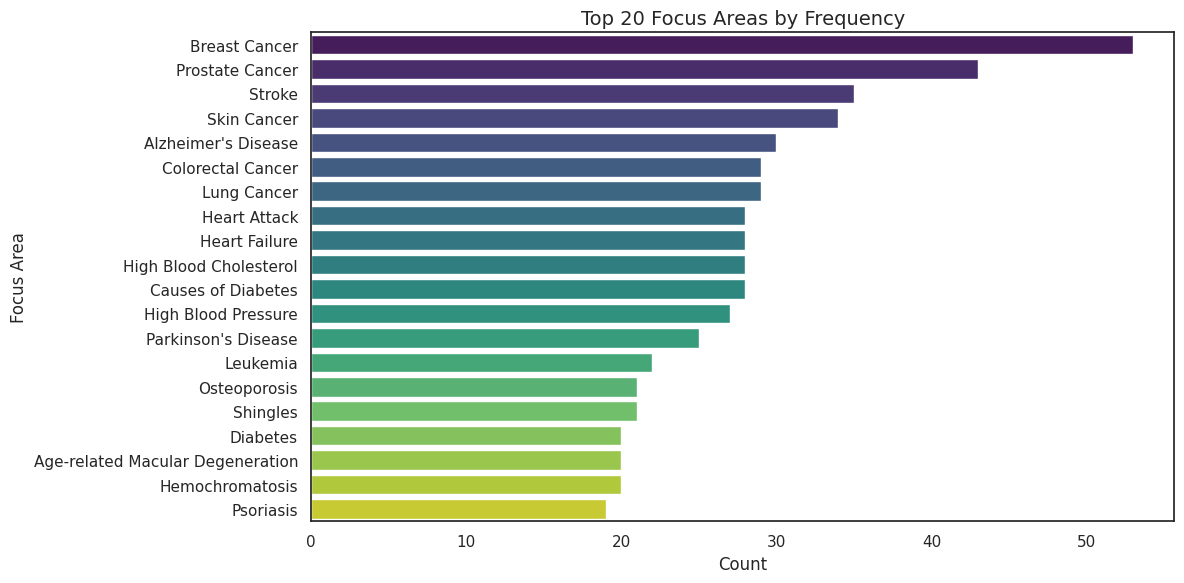

In [4]:
print(len(med_df['focus_area'].unique()))
top_focus_areas = med_df['focus_area'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_focus_areas.values, y=top_focus_areas.index, palette='viridis')
plt.title("Top 20 Focus Areas by Frequency", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Focus Area")
plt.tight_layout()
plt.show()

In [5]:
focus_areas = med_df["focus_area"].unique().tolist()

df_focus  = pd.DataFrame({'focus_area':focus_areas})
df_focus.to_csv('./focus_areas.csv',index = False)

docs = CSVLoader('./focus_areas.csv').load()
print(f"Loaded {len(docs)} amount of Focus Areas")


Loaded 5125 amount of Focus Areas


In [6]:
embeddings = OpenAIEmbeddings(model = "text-embedding-3-small")
vector_store = InMemoryVectorStore.from_documents(docs,embeddings)
related_docs = vector_store.similarity_search("cancer", k=150)
cancer_topics = [doc.page_content.split("focus_area: ")[1] for doc in related_docs]

print("Cancer-related focus areas found:", len(cancer_topics))

Cancer-related focus areas found: 150


In [7]:
cancer_df = med_df[med_df['focus_area'].isin(cancer_topics)]
print(f"Filtered dataset size: {cancer_df.shape}")

Filtered dataset size: (752, 4)


# Preview Sample Question Answer Dataset on Cancer

In [8]:
cancer_df.sample(5,random_state=42)[["focus_area","question","answer"]]

,focus_area,question,answer
5139,Familial prostate cancer,What are the symptoms of Familial prostate can...,What are the signs and symptoms of Familial pr...
5375,Peutz-Jeghers syndrome,What is (are) Peutz-Jeghers syndrome ?,Peutz-Jeghers syndrome (PJS) is an inherited c...
1757,Biopsy,Do you have information about Biopsy,Summary : A biopsy is a procedure that removes...
450,Leukemia,What is (are) Leukemia ?,Leukemia is a cancer of the blood cells. It is...
913,Small Cell Lung Cancer,What are the treatments for Small Cell Lung Ca...,Key Points\n - There are di...


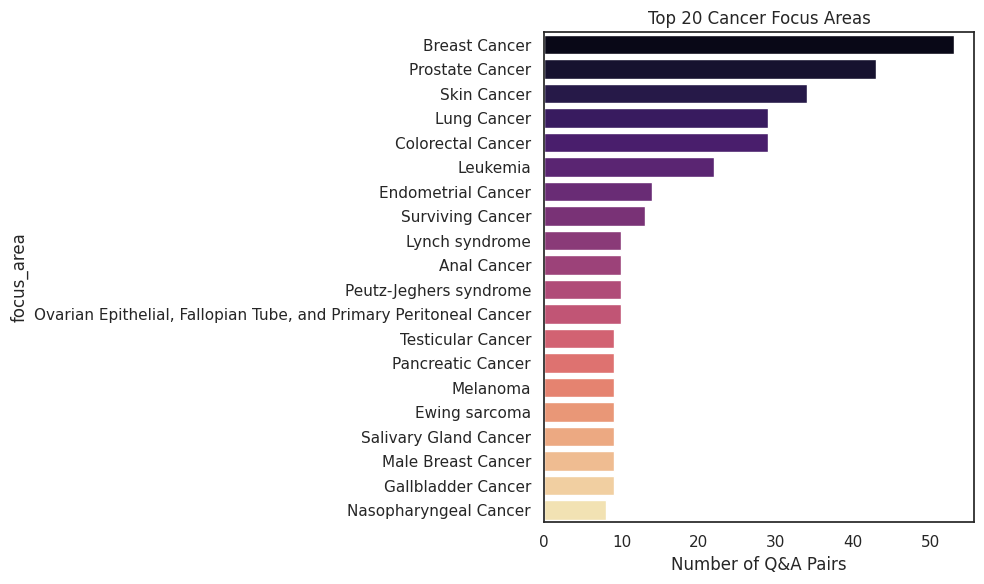

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=cancer_df, y='focus_area', order=cancer_df['focus_area'].value_counts().head(20).index, palette='magma')
plt.title("Top 20 Cancer Focus Areas")
plt.xlabel("Number of Q&A Pairs")
plt.tight_layout()
plt.show()

# Question Length Analysis

📝 Question length (words):
count    752.000000
mean       8.013298
std        2.210575
min        4.000000
25%        6.000000
50%        8.000000
75%        9.000000
max       18.000000
Name: question_length, dtype: float64


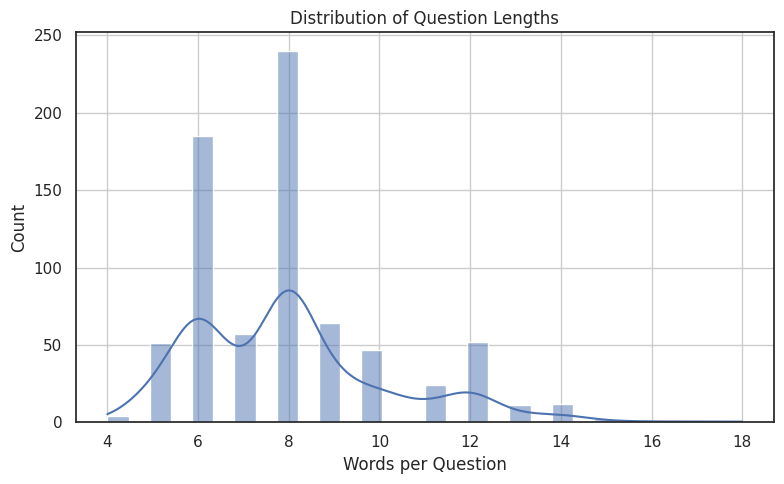

In [10]:

cancer_df['question_length'] = cancer_df['question'].apply(lambda x: len(str(x).split()))


print("📝 Question length (words):")
print(cancer_df['question_length'].describe())


plt.figure(figsize=(8, 5))
sns.histplot(cancer_df['question_length'], bins=30, kde=True)
plt.title("Distribution of Question Lengths")
plt.xlabel("Words per Question")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
from langchain_core.documents import Document
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
qa_docs = [
    Document(
        page_content=f"Question: {row['question']}\nAnswer: {row['answer']}",
        metadata={"focus_area": row["focus_area"]}
    )
    for _, row in cancer_df.iterrows()
]

# Question and Answer Embedding  

In [12]:
def embed_in_batches(documents, batch_size = 150):
    vector_store = InMemoryVectorStore(embedding=embeddings)
    for i in range(0, len(documents), batch_size):
        batch = documents[i:i + batch_size]
        vector_store.add_documents(batch)
    return vector_store
vector_store = embed_in_batches(qa_docs)
print(f" Vector store created with {len(qa_docs)} cancer Q&A documents.")

 Vector store created with 752 cancer Q&A documents.


In [13]:
results = vector_store.similarity_search("What are symptoms of prostate cancer?", k=3)
for doc in results:
    print(doc.page_content)
    print("---")

Question: What are the symptoms of Prostate Cancer ?
Answer: Signs of prostate cancer include a weak flow of urine or frequent urination. These and other signs and symptoms may be caused by prostate cancer or by other conditions. Check with your doctor if you have any of the following:         - Weak or interrupted ("stop-and-go") flow of urine.    - Sudden urge to urinate.    - Frequent urination (especially at night).    - Trouble starting the flow of urine.    - Trouble emptying the bladder completely.    - Pain or burning while urinating.    -  Blood in the urine or semen.    - A pain in the back, hips, or pelvis that doesn't go away.    - Shortness of breath, feeling very tired, fast heartbeat, dizziness, or pale skin caused by anemia.        Other conditions may cause the same symptoms. As men age, the prostate may get bigger and block the urethra or bladder. This may cause trouble urinating or sexual problems. The condition is called benign prostatic hyperplasia (BPH), and altho